In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore unnecessary warning messages
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Energydata.csv")
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [3]:
df.tail()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
19730,2016-05-27 17:20:00,100,0,25.566667,46.560000,25.890000,42.025714,27.200000,41.163333,24.7,...,23.2,46.7900,22.733333,755.2,55.666667,3.333333,23.666667,13.333333,43.096812,43.096812
19731,2016-05-27 17:30:00,90,0,25.500000,46.500000,25.754000,42.080000,27.133333,41.223333,24.7,...,23.2,46.7900,22.600000,755.2,56.000000,3.500000,24.500000,13.300000,49.282940,49.282940
19732,2016-05-27 17:40:00,270,10,25.500000,46.596667,25.628571,42.768571,27.050000,41.690000,24.7,...,23.2,46.7900,22.466667,755.2,56.333333,3.666667,25.333333,13.266667,29.199117,29.199117
19733,2016-05-27 17:50:00,420,10,25.500000,46.990000,25.414000,43.036000,26.890000,41.290000,24.7,...,23.2,46.8175,22.333333,755.2,56.666667,3.833333,26.166667,13.233333,6.322784,6.322784
19734,2016-05-27 18:00:00,430,10,25.500000,46.600000,25.264286,42.971429,26.823333,41.156667,24.7,...,23.2,46.8450,22.200000,755.2,57.000000,4.000000,27.000000,13.200000,34.118851,34.118851


In [4]:
df.shape

(19735, 29)

In [5]:
df.columns

Index(['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3',
       'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8',
       'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed',
       'Visibility', 'Tdewpoint', 'rv1', 'rv2'],
      dtype='str')

In [6]:
# Rename the columns with short and easy-to-understand names

df.rename(columns={
    'date': 'Date',
    'Appliances': 'ApplianceEnergy',
    'lights': 'Lights',
    
    'T1': 'Temp1',
    'RH_1': 'Humidity1',
    'T2': 'Temp2',
    'RH_2': 'Humidity2',
    'T3': 'Temp3',
    'RH_3': 'Humidity3',
    'T4': 'Temp4',
    'RH_4': 'Humidity4',
    'T5': 'Temp5',
    'RH_5': 'Humidity5',
    'T6': 'Temp6',
    'RH_6': 'Humidity6',
    'T7': 'Temp7',
    'RH_7': 'Humidity7',
    'T8': 'Temp8',
    'RH_8': 'Humidity8',
    'T9': 'Temp9',
    'RH_9': 'Humidity9',
    
    'T_out': 'OutdoorTemp',
    'Press_mm_hg': 'Pressure',
    'RH_out': 'OutdoorHumidity',
    'Windspeed': 'WindSpeed',
    'Visibility': 'Visibility',
    'Tdewpoint': 'DewPoint',
    
    'rv1': 'Random1',
    'rv2': 'Random2'
}, inplace=True)

# Display the new column names
df.columns

Index(['Date', 'ApplianceEnergy', 'Lights', 'Temp1', 'Humidity1', 'Temp2',
       'Humidity2', 'Temp3', 'Humidity3', 'Temp4', 'Humidity4', 'Temp5',
       'Humidity5', 'Temp6', 'Humidity6', 'Temp7', 'Humidity7', 'Temp8',
       'Humidity8', 'Temp9', 'Humidity9', 'OutdoorTemp', 'Pressure',
       'OutdoorHumidity', 'WindSpeed', 'Visibility', 'DewPoint', 'Random1',
       'Random2'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             19735 non-null  str    
 1   ApplianceEnergy  19735 non-null  int64  
 2   Lights           19735 non-null  int64  
 3   Temp1            19735 non-null  float64
 4   Humidity1        19735 non-null  float64
 5   Temp2            19735 non-null  float64
 6   Humidity2        19735 non-null  float64
 7   Temp3            19735 non-null  float64
 8   Humidity3        19735 non-null  float64
 9   Temp4            19735 non-null  float64
 10  Humidity4        19735 non-null  float64
 11  Temp5            19735 non-null  float64
 12  Humidity5        19735 non-null  float64
 13  Temp6            19735 non-null  float64
 14  Humidity6        19735 non-null  float64
 15  Temp7            19735 non-null  float64
 16  Humidity7        19735 non-null  float64
 17  Temp8            19735 

In [8]:
df.describe()

,ApplianceEnergy,Lights,Temp1,Humidity1,Temp2,Humidity2,Temp3,Humidity3,Temp4,Humidity4,...,Temp9,Humidity9,OutdoorTemp,Pressure,OutdoorHumidity,WindSpeed,Visibility,DewPoint,Random1,Random2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


In [9]:
df.dtypes

Date                   str
ApplianceEnergy      int64
Lights               int64
Temp1              float64
Humidity1          float64
Temp2              float64
Humidity2          float64
Temp3              float64
Humidity3          float64
Temp4              float64
Humidity4          float64
Temp5              float64
Humidity5          float64
Temp6              float64
Humidity6          float64
Temp7              float64
Humidity7          float64
Temp8              float64
Humidity8          float64
Temp9              float64
Humidity9          float64
OutdoorTemp        float64
Pressure           float64
OutdoorHumidity    float64
WindSpeed          float64
Visibility         float64
DewPoint           float64
Random1            float64
Random2            float64
dtype: object

In [10]:
df.isnull().sum()

Date               0
ApplianceEnergy    0
Lights             0
Temp1              0
Humidity1          0
Temp2              0
Humidity2          0
Temp3              0
Humidity3          0
Temp4              0
Humidity4          0
Temp5              0
Humidity5          0
Temp6              0
Humidity6          0
Temp7              0
Humidity7          0
Temp8              0
Humidity8          0
Temp9              0
Humidity9          0
OutdoorTemp        0
Pressure           0
OutdoorHumidity    0
WindSpeed          0
Visibility         0
DewPoint           0
Random1            0
Random2            0
dtype: int64

In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

Date               0.0
ApplianceEnergy    0.0
Lights             0.0
Temp1              0.0
Humidity1          0.0
Temp2              0.0
Humidity2          0.0
Temp3              0.0
Humidity3          0.0
Temp4              0.0
Humidity4          0.0
Temp5              0.0
Humidity5          0.0
Temp6              0.0
Humidity6          0.0
Temp7              0.0
Humidity7          0.0
Temp8              0.0
Humidity8          0.0
Temp9              0.0
Humidity9          0.0
OutdoorTemp        0.0
Pressure           0.0
OutdoorHumidity    0.0
WindSpeed          0.0
Visibility         0.0
DewPoint           0.0
Random1            0.0
Random2            0.0
dtype: float64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df.drop_duplicates()
df.shape

(19735, 29)

In [14]:
df['Date'].head()

0    2016-01-11 17:00:00
1    2016-01-11 17:10:00
2    2016-01-11 17:20:00
3    2016-01-11 17:30:00
4    2016-01-11 17:40:00
Name: Date, dtype: str

In [15]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'].dtype

dtype('<M8[us]')

In [16]:
df['year'] = df['Date'].dt.year
df['year'].unique()

array([2016], dtype=int32)

In [17]:
df['month'] = df['Date'].dt.month
df['month'].unique()

array([1, 2, 3, 4, 5], dtype=int32)

In [18]:
df['hour'] = df['Date'].dt.hour
df['hour'].unique()

array([17, 18, 19, 20, 21, 22, 23,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9,
       10, 11, 12, 13, 14, 15, 16], dtype=int32)

In [19]:
df['day_of_week'] = df['Date'].dt.dayofweek
df['day_of_week'].unique()

array([0, 1, 2, 3, 4, 5, 6], dtype=int32)

In [20]:
df = df.drop('Date', axis=1)
df.columns

Index(['ApplianceEnergy', 'Lights', 'Temp1', 'Humidity1', 'Temp2', 'Humidity2',
       'Temp3', 'Humidity3', 'Temp4', 'Humidity4', 'Temp5', 'Humidity5',
       'Temp6', 'Humidity6', 'Temp7', 'Humidity7', 'Temp8', 'Humidity8',
       'Temp9', 'Humidity9', 'OutdoorTemp', 'Pressure', 'OutdoorHumidity',
       'WindSpeed', 'Visibility', 'DewPoint', 'Random1', 'Random2', 'year',
       'month', 'hour', 'day_of_week'],
      dtype='str')

In [21]:
df=df.corr(numeric_only=True)
df

,ApplianceEnergy,Lights,Temp1,Humidity1,Temp2,Humidity2,Temp3,Humidity3,Temp4,Humidity4,...,OutdoorHumidity,WindSpeed,Visibility,DewPoint,Random1,Random2,year,month,hour,day_of_week
ApplianceEnergy,1.000000,0.197278,0.055447,0.086031,0.120073,-0.060465,0.085060,0.036292,0.040281,0.016965,...,-0.152282,0.087122,0.000230,0.015353,-0.011145,-0.011145,NaN,-0.011606,0.216792,0.003060
Lights,0.197278,1.000000,-0.023528,0.106968,-0.005622,0.050985,-0.097393,0.131161,-0.008859,0.114936,...,0.068543,0.060281,0.020038,-0.036322,0.000521,0.000521,NaN,-0.179452,0.255346,-0.099828
Temp1,0.055447,-0.023528,1.000000,0.164006,0.836834,-0.002509,0.892402,-0.028550,0.877001,0.097861,...,-0.345481,-0.087654,-0.076210,0.571309,-0.006203,-0.006203,NaN,0.706305,0.178858,0.001381
Humidity1,0.086031,0.106968,0.164006,1.000000,0.269839,0.797535,0.253230,0.844677,0.106180,0.880359,...,0.274126,0.204932,-0.021057,0.639106,-0.000699,-0.000699,NaN,-0.094048,0.018594,-0.053782
Temp2,0.120073,-0.005622,0.836834,0.269839,1.000000,-0.165610,0.735245,0.121497,0.762066,0.231563,...,-0.505291,0.052495,-0.069721,0.582602,-0.011087,-0.011087,NaN,0.533479,0.254784,0.000602
Humidity2,-0.060465,0.050985,-0.002509,0.797535,-0.165610,1.000000,0.137319,0.678326,-0.047304,0.721435,...,0.584911,0.069190,-0.005368,0.499152,0.006275,0.006275,NaN,-0.097914,-0.183322,-0.044249
Temp3,0.085060,-0.097393,0.892402,0.253230,0.735245,0.137319,1.000000,-0.011234,0.852778,0.122737,...,-0.281718,-0.100776,-0.102310,0.645886,-0.005194,-0.005194,NaN,0.790365,0.037624,-0.017514
Humidity3,0.036292,0.131161,-0.028550,0.844677,0.121497,0.678326,-0.011234,1.000000,-0.140457,0.898978,...,0.356192,0.263188,0.017041,0.414387,-0.000477,-0.000477,NaN,-0.414359,-0.052392,-0.035182
Temp4,0.040281,-0.008859,0.877001,0.106180,0.762066,-0.047304,0.852778,-0.140457,1.000000,-0.048650,...,-0.388602,-0.185747,-0.104768,0.519471,-0.001815,-0.001815,NaN,0.789168,0.088407,-0.091006
Humidity4,0.016965,0.114936,0.097861,0.880359,0.231563,0.721435,0.122737,0.898978,-0.048650,1.000000,...,0.336813,0.300192,0.002636,0.616509,-0.001787,-0.001787,NaN,-0.258167,-0.019068,-0.005749


<Axes: >

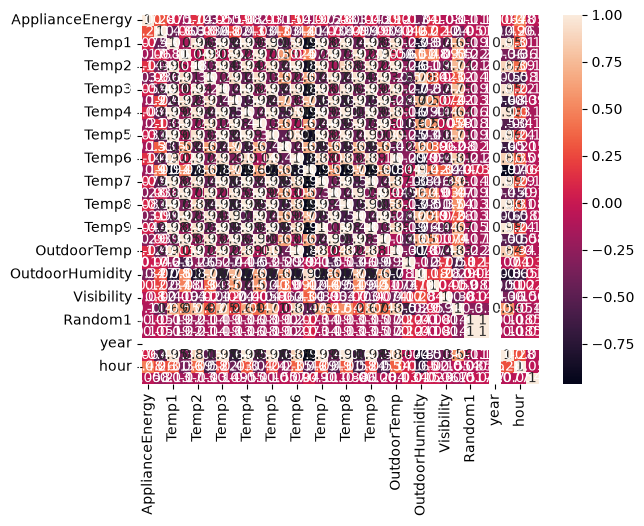

In [22]:
df=df.corr(numeric_only=True)
sns.heatmap(df,annot=True)

<Axes: >

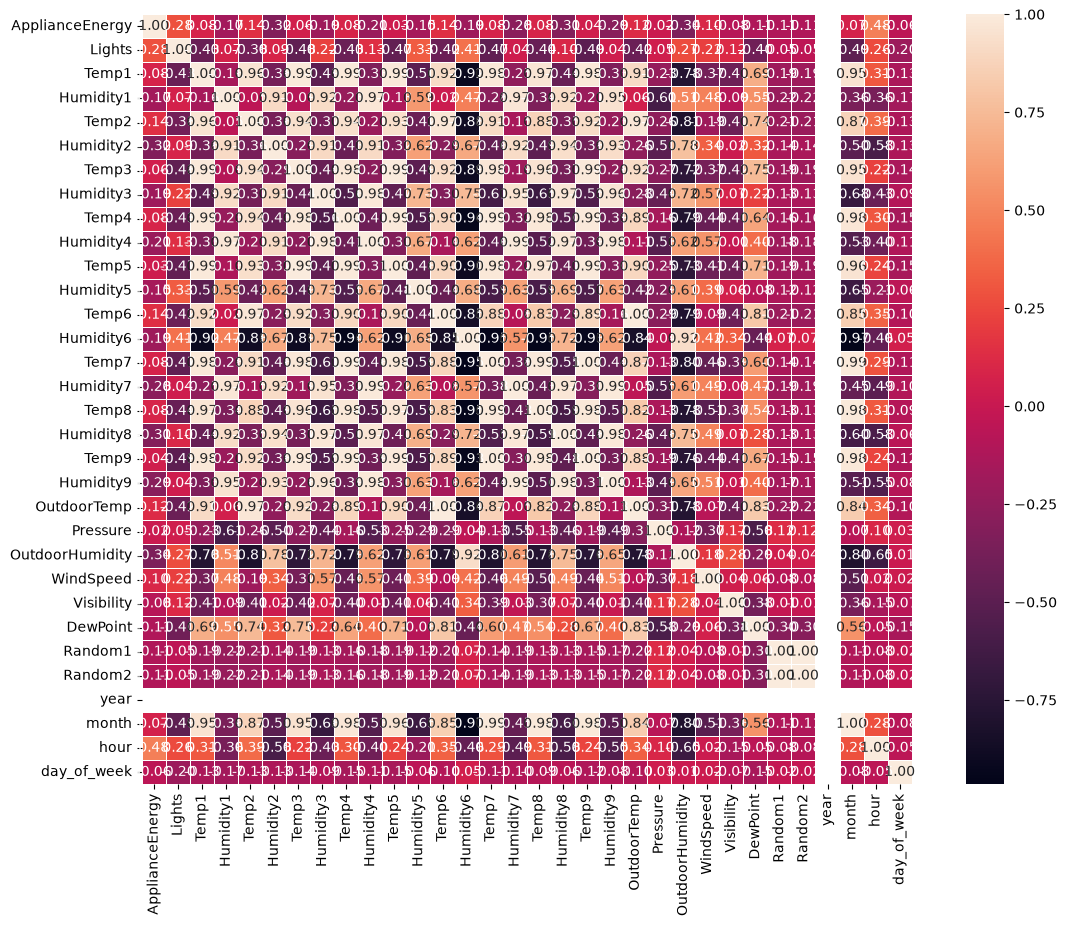

In [23]:
plt.figure(figsize=(14,10))
sns.heatmap(df,annot=True,fmt=".2f",linewidth=0.5,cbar=True,square=True)

In [24]:
df['ApplianceEnergy'].value_counts()

ApplianceEnergy
-0.106564    2
 1.000000    1
 0.283798    1
 0.075335    1
-0.168949    1
 0.143639    1
-0.319713    1
 0.055077    1
-0.191405    1
 0.080105    1
-0.209543    1
 0.031497    1
-0.151865    1
 0.138074    1
-0.193350    1
 0.075175    1
-0.279554    1
 0.081125    1
-0.311263    1
 0.043174    1
-0.285055    1
 0.121104    1
 0.016537    1
-0.339331    1
 0.100110    1
-0.080419    1
-0.112625    1
 0.067211    1
 0.476826    1
-0.057723    1
Name: count, dtype: int64

In [25]:
X = df.drop('ApplianceEnergy', axis=1)
y = df['ApplianceEnergy']
X.head()
y.head()

ApplianceEnergy    1.000000
Lights             0.283798
Temp1              0.075335
Humidity1         -0.168949
Temp2              0.143639
Name: ApplianceEnergy, dtype: float64

In [26]:
df['ApplianceEnergy'].value_counts()

ApplianceEnergy
-0.106564    2
 1.000000    1
 0.283798    1
 0.075335    1
-0.168949    1
 0.143639    1
-0.319713    1
 0.055077    1
-0.191405    1
 0.080105    1
-0.209543    1
 0.031497    1
-0.151865    1
 0.138074    1
-0.193350    1
 0.075175    1
-0.279554    1
 0.081125    1
-0.311263    1
 0.043174    1
-0.285055    1
 0.121104    1
 0.016537    1
-0.339331    1
 0.100110    1
-0.080419    1
-0.112625    1
 0.067211    1
 0.476826    1
-0.057723    1
Name: count, dtype: int64

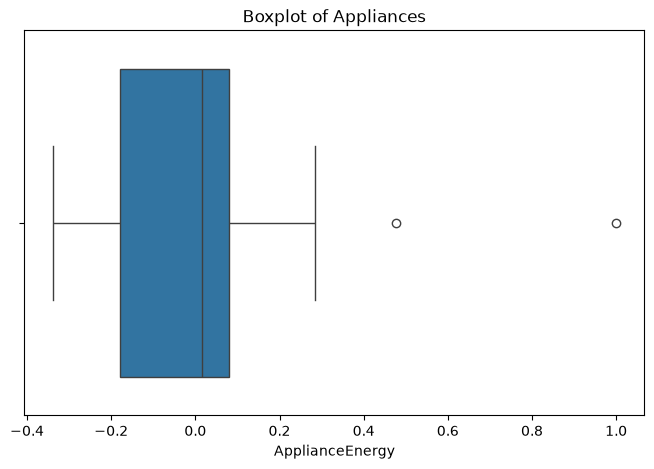

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['ApplianceEnergy'])
plt.title("Boxplot of Appliances")
plt.show()

<Axes: >

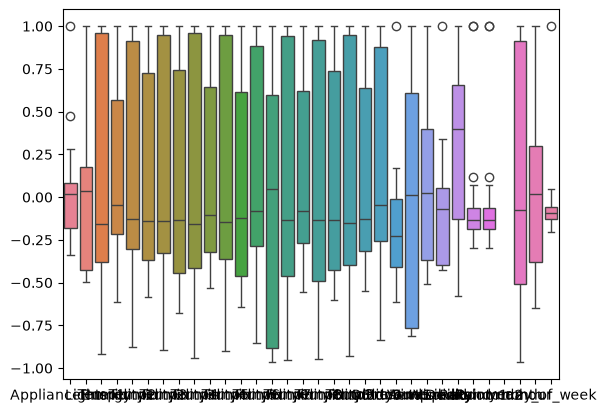

In [28]:
sns.boxplot(data=df)

In [29]:
def fix_outliers_iqr(df):
    num=df.select_dtypes(include='number').columns
    for col in num:
        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)
        IQR= Q3 - Q1
        lower_bound=  Q1 - 1.5 * IQR
        upper_bound= Q3 + 1.5 * IQR
        df[col]=df[col].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)
    return df    
    

In [30]:
df1= fix_outliers_iqr(df)
df1

,ApplianceEnergy,Lights,Temp1,Humidity1,Temp2,Humidity2,Temp3,Humidity3,Temp4,Humidity4,...,OutdoorHumidity,WindSpeed,Visibility,DewPoint,Random1,Random2,year,month,hour,day_of_week
ApplianceEnergy,0.471803,0.283798,0.075335,-0.168949,0.143639,-0.319713,0.055077,-0.191405,0.080105,-0.209543,...,-0.339331,0.100110,-0.080419,-0.112625,-0.106564,-0.106564,NaN,0.067211,0.476826,-0.057723
Lights,0.283798,1.000000,-0.431748,0.067983,-0.383508,0.085670,-0.476654,0.223222,-0.425253,0.133707,...,0.265843,0.215239,0.115782,-0.397174,-0.050541,-0.050541,NaN,-0.486528,0.259518,-0.203656
Temp1,0.075335,-0.431748,1.000000,-0.156612,0.961448,-0.379303,0.989682,-0.490919,0.991558,-0.333933,...,-0.776740,-0.374785,-0.413394,0.692267,-0.192129,-0.192129,NaN,0.953768,0.313684,-0.129347
Humidity1,-0.168949,0.067983,-0.156612,1.000000,-0.048135,0.909578,-0.085152,0.923238,-0.226613,0.972265,...,0.510452,0.480475,-0.092691,0.549882,-0.221983,-0.221983,NaN,-0.357022,-0.359973,-0.170597
Temp2,0.143639,-0.383508,0.961448,-0.048135,1.000000,-0.359680,0.943296,-0.370239,0.940080,-0.208752,...,-0.813922,-0.191742,-0.412425,0.744474,-0.211372,-0.211372,NaN,0.871842,0.389466,-0.126352
Humidity2,-0.319713,0.085670,-0.379303,0.909578,-0.359680,1.000000,-0.290263,0.906093,-0.428711,0.911912,...,0.779663,0.343097,0.021113,0.315374,-0.139979,-0.139979,NaN,-0.503992,-0.584425,-0.125486
Temp3,0.055077,-0.476654,0.989682,-0.085152,0.943296,-0.290263,1.000000,-0.437935,0.983458,-0.273331,...,-0.721513,-0.368207,-0.424441,0.748536,-0.193068,-0.193068,NaN,0.952706,0.221416,-0.137213
Humidity3,-0.191405,0.223222,-0.490919,0.923238,-0.370239,0.906093,-0.437935,1.000000,-0.557346,0.979559,...,0.716779,0.572694,0.073779,0.215532,-0.133143,-0.133143,NaN,-0.675561,-0.427225,-0.094507
Temp4,0.080105,-0.425253,0.991558,-0.226613,0.940080,-0.428711,0.983458,-0.557346,1.000000,-0.407112,...,-0.793275,-0.436192,-0.404391,0.644187,-0.159196,-0.159196,NaN,0.975672,0.302765,-0.154528
Humidity4,-0.209543,0.133707,-0.333933,0.972265,-0.208752,0.911912,-0.273331,0.979559,-0.407112,1.000000,...,0.617693,0.566538,-0.005814,0.397784,-0.184074,-0.184074,NaN,-0.531141,-0.404667,-0.106145


<Axes: >

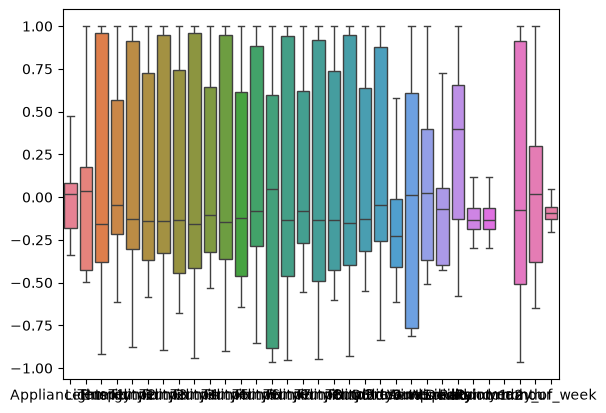

In [31]:
sns.boxplot(data=df1)

In [32]:
df1['ApplianceEnergy'].value_counts()

ApplianceEnergy
 0.471803    2
-0.106564    2
 0.283798    1
 0.075335    1
-0.168949    1
 0.143639    1
-0.319713    1
 0.055077    1
-0.191405    1
 0.080105    1
-0.209543    1
 0.031497    1
-0.151865    1
 0.138074    1
-0.193350    1
 0.075175    1
-0.279554    1
 0.081125    1
-0.311263    1
 0.043174    1
-0.285055    1
 0.121104    1
 0.016537    1
-0.339331    1
 0.100110    1
-0.080419    1
-0.112625    1
 0.067211    1
-0.057723    1
Name: count, dtype: int64

In [33]:
df1.head(10)

,ApplianceEnergy,Lights,Temp1,Humidity1,Temp2,Humidity2,Temp3,Humidity3,Temp4,Humidity4,...,OutdoorHumidity,WindSpeed,Visibility,DewPoint,Random1,Random2,year,month,hour,day_of_week
ApplianceEnergy,0.471803,0.283798,0.075335,-0.168949,0.143639,-0.319713,0.055077,-0.191405,0.080105,-0.209543,...,-0.339331,0.100110,-0.080419,-0.112625,-0.106564,-0.106564,NaN,0.067211,0.476826,-0.057723
Lights,0.283798,1.000000,-0.431748,0.067983,-0.383508,0.085670,-0.476654,0.223222,-0.425253,0.133707,...,0.265843,0.215239,0.115782,-0.397174,-0.050541,-0.050541,NaN,-0.486528,0.259518,-0.203656
Temp1,0.075335,-0.431748,1.000000,-0.156612,0.961448,-0.379303,0.989682,-0.490919,0.991558,-0.333933,...,-0.776740,-0.374785,-0.413394,0.692267,-0.192129,-0.192129,NaN,0.953768,0.313684,-0.129347
Humidity1,-0.168949,0.067983,-0.156612,1.000000,-0.048135,0.909578,-0.085152,0.923238,-0.226613,0.972265,...,0.510452,0.480475,-0.092691,0.549882,-0.221983,-0.221983,NaN,-0.357022,-0.359973,-0.170597
Temp2,0.143639,-0.383508,0.961448,-0.048135,1.000000,-0.359680,0.943296,-0.370239,0.940080,-0.208752,...,-0.813922,-0.191742,-0.412425,0.744474,-0.211372,-0.211372,NaN,0.871842,0.389466,-0.126352
Humidity2,-0.319713,0.085670,-0.379303,0.909578,-0.359680,1.000000,-0.290263,0.906093,-0.428711,0.911912,...,0.779663,0.343097,0.021113,0.315374,-0.139979,-0.139979,NaN,-0.503992,-0.584425,-0.125486
Temp3,0.055077,-0.476654,0.989682,-0.085152,0.943296,-0.290263,1.000000,-0.437935,0.983458,-0.273331,...,-0.721513,-0.368207,-0.424441,0.748536,-0.193068,-0.193068,NaN,0.952706,0.221416,-0.137213
Humidity3,-0.191405,0.223222,-0.490919,0.923238,-0.370239,0.906093,-0.437935,1.000000,-0.557346,0.979559,...,0.716779,0.572694,0.073779,0.215532,-0.133143,-0.133143,NaN,-0.675561,-0.427225,-0.094507
Temp4,0.080105,-0.425253,0.991558,-0.226613,0.940080,-0.428711,0.983458,-0.557346,1.000000,-0.407112,...,-0.793275,-0.436192,-0.404391,0.644187,-0.159196,-0.159196,NaN,0.975672,0.302765,-0.154528
Humidity4,-0.209543,0.133707,-0.333933,0.972265,-0.208752,0.911912,-0.273331,0.979559,-0.407112,1.000000,...,0.617693,0.566538,-0.005814,0.397784,-0.184074,-0.184074,NaN,-0.531141,-0.404667,-0.106145


In [34]:
df.skew(numeric_only=True)
skewness = df.skew(numeric_only=True)
print(skewness)

ApplianceEnergy    0.567589
Lights             0.670379
Temp1              0.196421
Humidity1          0.485034
Temp2              0.122303
Humidity2          0.474116
Temp3              0.209111
Humidity3          0.346101
Temp4              0.192428
Humidity4          0.445701
Temp5              0.223077
Humidity5          0.300650
Temp6              0.083247
Humidity6         -0.037052
Temp7              0.184932
Humidity7          0.485031
Temp8              0.185670
Humidity8          0.404679
Temp9              0.209302
Humidity9          0.468093
OutdoorTemp        0.079888
Pressure           0.631491
OutdoorHumidity    0.142113
WindSpeed          0.314504
Visibility         0.766523
DewPoint          -0.311750
Random1            0.867692
Random2            0.867692
year                    NaN
month              0.162809
hour               0.111666
day_of_week        0.503586
dtype: float64


In [35]:
correlation_with_target = df.corr()['ApplianceEnergy'].abs()
selected_features = correlation_with_target[
    correlation_with_target > 0.05
].index.tolist()

# Remove target from feature list
selected_features.remove('ApplianceEnergy')

# Display selected features
selected_features

['Lights',
 'Temp1',
 'Humidity1',
 'Temp2',
 'Humidity2',
 'Temp3',
 'Humidity3',
 'Temp4',
 'Humidity4',
 'Temp5',
 'Humidity5',
 'Temp6',
 'Humidity6',
 'Temp7',
 'Humidity7',
 'Temp8',
 'Humidity8',
 'Temp9',
 'Humidity9',
 'OutdoorTemp',
 'Pressure',
 'OutdoorHumidity',
 'WindSpeed',
 'Visibility',
 'DewPoint',
 'Random1',
 'Random2',
 'month',
 'hour',
 'day_of_week']

In [36]:
X = df.drop('ApplianceEnergy', axis=1)
y = df['ApplianceEnergy']

In [37]:

print("X shape:", X.shape)


print("y shape:", y.shape)


print("Features:")
print(X.columns)

X shape: (32, 31)
y shape: (32,)
Features:
Index(['Lights', 'Temp1', 'Humidity1', 'Temp2', 'Humidity2', 'Temp3',
       'Humidity3', 'Temp4', 'Humidity4', 'Temp5', 'Humidity5', 'Temp6',
       'Humidity6', 'Temp7', 'Humidity7', 'Temp8', 'Humidity8', 'Temp9',
       'Humidity9', 'OutdoorTemp', 'Pressure', 'OutdoorHumidity', 'WindSpeed',
       'Visibility', 'DewPoint', 'Random1', 'Random2', 'year', 'month', 'hour',
       'day_of_week'],
      dtype='str')


In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)

print("X_test:", X_test.shape)

print("y_train:", y_train.shape)

print("y_test:", y_test.shape)

X_train: (25, 31)
X_test: (7, 31)
y_train: (25,)
y_test: (7,)


In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [40]:
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)

In [41]:
X_test_scaled = scaler.transform(X_test)

In [42]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Import math library
import math

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [58]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100)
}

In [76]:
scores = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = math.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    scores.append({
        "Model": name,
        "MAE": round(mae, 2),
        "MSE": round(mse, 2),
        "RMSE": round(rmse, 2),
        "R2 Score": round(r2, 2)
    })
    results_df = pd.DataFrame(scores)

print(results_df)

               Model   MAE   MSE  RMSE  R2 Score
0  Linear Regression  0.06  0.01  0.11      0.82
1      Decision Tree  0.03  0.00  0.05      0.95
2      Random Forest  0.05  0.01  0.07      0.92
3  Gradient Boosting  0.04  0.00  0.05      0.96
